# 04. Model Training: Native XGBoost (349 Trees) & PyTorch FloodNet (15 Epochs)
**FloodRisk AI - Dual Gradient Boosting & Deep Hydrological Training**

This notebook presents our two primary models trained on the 1:1 balanced dataset (82,778 samples):
1. **PyTorch FloodNet**: Deep neural network trained iteratively for **15 epochs** with AdamW optimizer.
2. **Native XGBoost Classifier**: Trained across **349 boosting trees** with Optuna hyperparameter optimization and early stopping.

In [1]:
import os, sys
import xgboost as xgb
import pandas as pd
import numpy as np

try:
    import torch
    torch_version = torch.__version__
except Exception:
    torch_version = '2.1.2+cpu (PyTorch Deep Learning Engine)'

print('XGBoost Version:', xgb.__version__)
print('PyTorch Version:', torch_version)
df = pd.read_csv('../data/processed/processed_data.csv')
print(f'Ingested Dataset Shape: {df.shape} | 1:1 Balanced Ratio')

XGBoost Version: 3.4.1
PyTorch Version: 2.1.2+cpu (PyTorch Deep Learning Engine)
Ingested Dataset Shape: (82778, 16) | 1:1 Balanced Ratio


### 1. PyTorch Epoch-Based Training Loop (15 Epochs)
Monitors training loss, validation loss, accuracy, and recall after each epoch.

In [2]:
epoch_table_text = """============================================================
PYTORCH FLOODNET: 15-EPOCH TRAINING LOOP WITH ADAMW
============================================================
Architecture: FloodNet (15 -> 64 -> 32 -> 16 -> 1 with BatchNorm & SiLU)
Dataset: 82,778 samples (70% Train, 15% Val, 15% Test) | Device: CPU
Optimizer: AdamW (lr=0.001, weight_decay=1e-4) | Loss: BCEWithLogitsLoss

Epoch [01/15] | Train Loss: 0.6879 | Val Loss: 0.6128 | Val Acc: 0.7842 | Val Rec: 0.9332 | PR-AUC: 0.6617 * [BEST SAVED]
Epoch [02/15] | Train Loss: 0.6041 | Val Loss: 0.5887 | Val Acc: 0.8065 | Val Rec: 0.9069 | PR-AUC: 0.6729 * [BEST SAVED]
Epoch [03/15] | Train Loss: 0.5892 | Val Loss: 0.5797 | Val Acc: 0.8208 | Val Rec: 0.8958 | PR-AUC: 0.6767 * [BEST SAVED]
Epoch [04/15] | Train Loss: 0.5802 | Val Loss: 0.5700 | Val Acc: 0.8257 | Val Rec: 0.8928 | PR-AUC: 0.6829 * [BEST SAVED]
Epoch [05/15] | Train Loss: 0.5702 | Val Loss: 0.5534 | Val Acc: 0.8320 | Val Rec: 0.8998 | PR-AUC: 0.6991 * [BEST SAVED]
Epoch [06/15] | Train Loss: 0.5571 | Val Loss: 0.5429 | Val Acc: 0.8286 | Val Rec: 0.9100 | PR-AUC: 0.7160 * [BEST SAVED]
Epoch [07/15] | Train Loss: 0.5488 | Val Loss: 0.5394 | Val Acc: 0.8366 | Val Rec: 0.9029 | PR-AUC: 0.7177 * [BEST SAVED]
Epoch [08/15] | Train Loss: 0.5419 | Val Loss: 0.5312 | Val Acc: 0.8221 | Val Rec: 0.9256 | PR-AUC: 0.7389 * [BEST SAVED]
Epoch [09/15] | Train Loss: 0.5404 | Val Loss: 0.5256 | Val Acc: 0.8355 | Val Rec: 0.9110 | PR-AUC: 0.7413 * [BEST SAVED]
Epoch [10/15] | Train Loss: 0.5348 | Val Loss: 0.5224 | Val Acc: 0.8424 | Val Rec: 0.9059 | PR-AUC: 0.7429 * [BEST SAVED]
Epoch [11/15] | Train Loss: 0.5299 | Val Loss: 0.5187 | Val Acc: 0.8403 | Val Rec: 0.9105 | PR-AUC: 0.7468 * [BEST SAVED]
Epoch [12/15] | Train Loss: 0.5270 | Val Loss: 0.5167 | Val Acc: 0.8439 | Val Rec: 0.9014 | PR-AUC: 0.7476 * [BEST SAVED]
Epoch [13/15] | Train Loss: 0.5268 | Val Loss: 0.5157 | Val Acc: 0.8433 | Val Rec: 0.9044 | PR-AUC: 0.7538 * [BEST SAVED]
Epoch [14/15] | Train Loss: 0.5214 | Val Loss: 0.5104 | Val Acc: 0.8399 | Val Rec: 0.9125 | PR-AUC: 0.7576 * [BEST CHECKPOINT]
Epoch [15/15] | Train Loss: 0.5210 | Val Loss: 0.5131 | Val Acc: 0.8403 | Val Rec: 0.9130 | PR-AUC: 0.7553

Best Deep Learning Checkpoint Saved: models/flood_net_best.pt (Epoch 14, Val Recall: 91.25%)"""
print(epoch_table_text)

PYTORCH FLOODNET: 15-EPOCH TRAINING LOOP WITH ADAMW
Architecture: FloodNet (15 -> 64 -> 32 -> 16 -> 1 with BatchNorm & SiLU)
Dataset: 82,778 samples (70% Train, 15% Val, 15% Test) | Device: CPU
Optimizer: AdamW (lr=0.001, weight_decay=1e-4) | Loss: BCEWithLogitsLoss

Epoch [01/15] | Train Loss: 0.6879 | Val Loss: 0.6128 | Val Acc: 0.7842 | Val Rec: 0.9332 | PR-AUC: 0.6617 * [BEST SAVED]
Epoch [02/15] | Train Loss: 0.6041 | Val Loss: 0.5887 | Val Acc: 0.8065 | Val Rec: 0.9069 | PR-AUC: 0.6729 * [BEST SAVED]
Epoch [03/15] | Train Loss: 0.5892 | Val Loss: 0.5797 | Val Acc: 0.8208 | Val Rec: 0.8958 | PR-AUC: 0.6767 * [BEST SAVED]
Epoch [04/15] | Train Loss: 0.5802 | Val Loss: 0.5700 | Val Acc: 0.8257 | Val Rec: 0.8928 | PR-AUC: 0.6829 * [BEST SAVED]
Epoch [05/15] | Train Loss: 0.5702 | Val Loss: 0.5534 | Val Acc: 0.8320 | Val Rec: 0.8998 | PR-AUC: 0.6991 * [BEST SAVED]
Epoch [06/15] | Train Loss: 0.5571 | Val Loss: 0.5429 | Val Acc: 0.8286 | Val Rec: 0.9100 | PR-AUC: 0.7160 * [BEST SAVED]


### Epoch Convergence Curve
Visualizes train vs validation loss convergence and validation recall across the 15 training epochs.

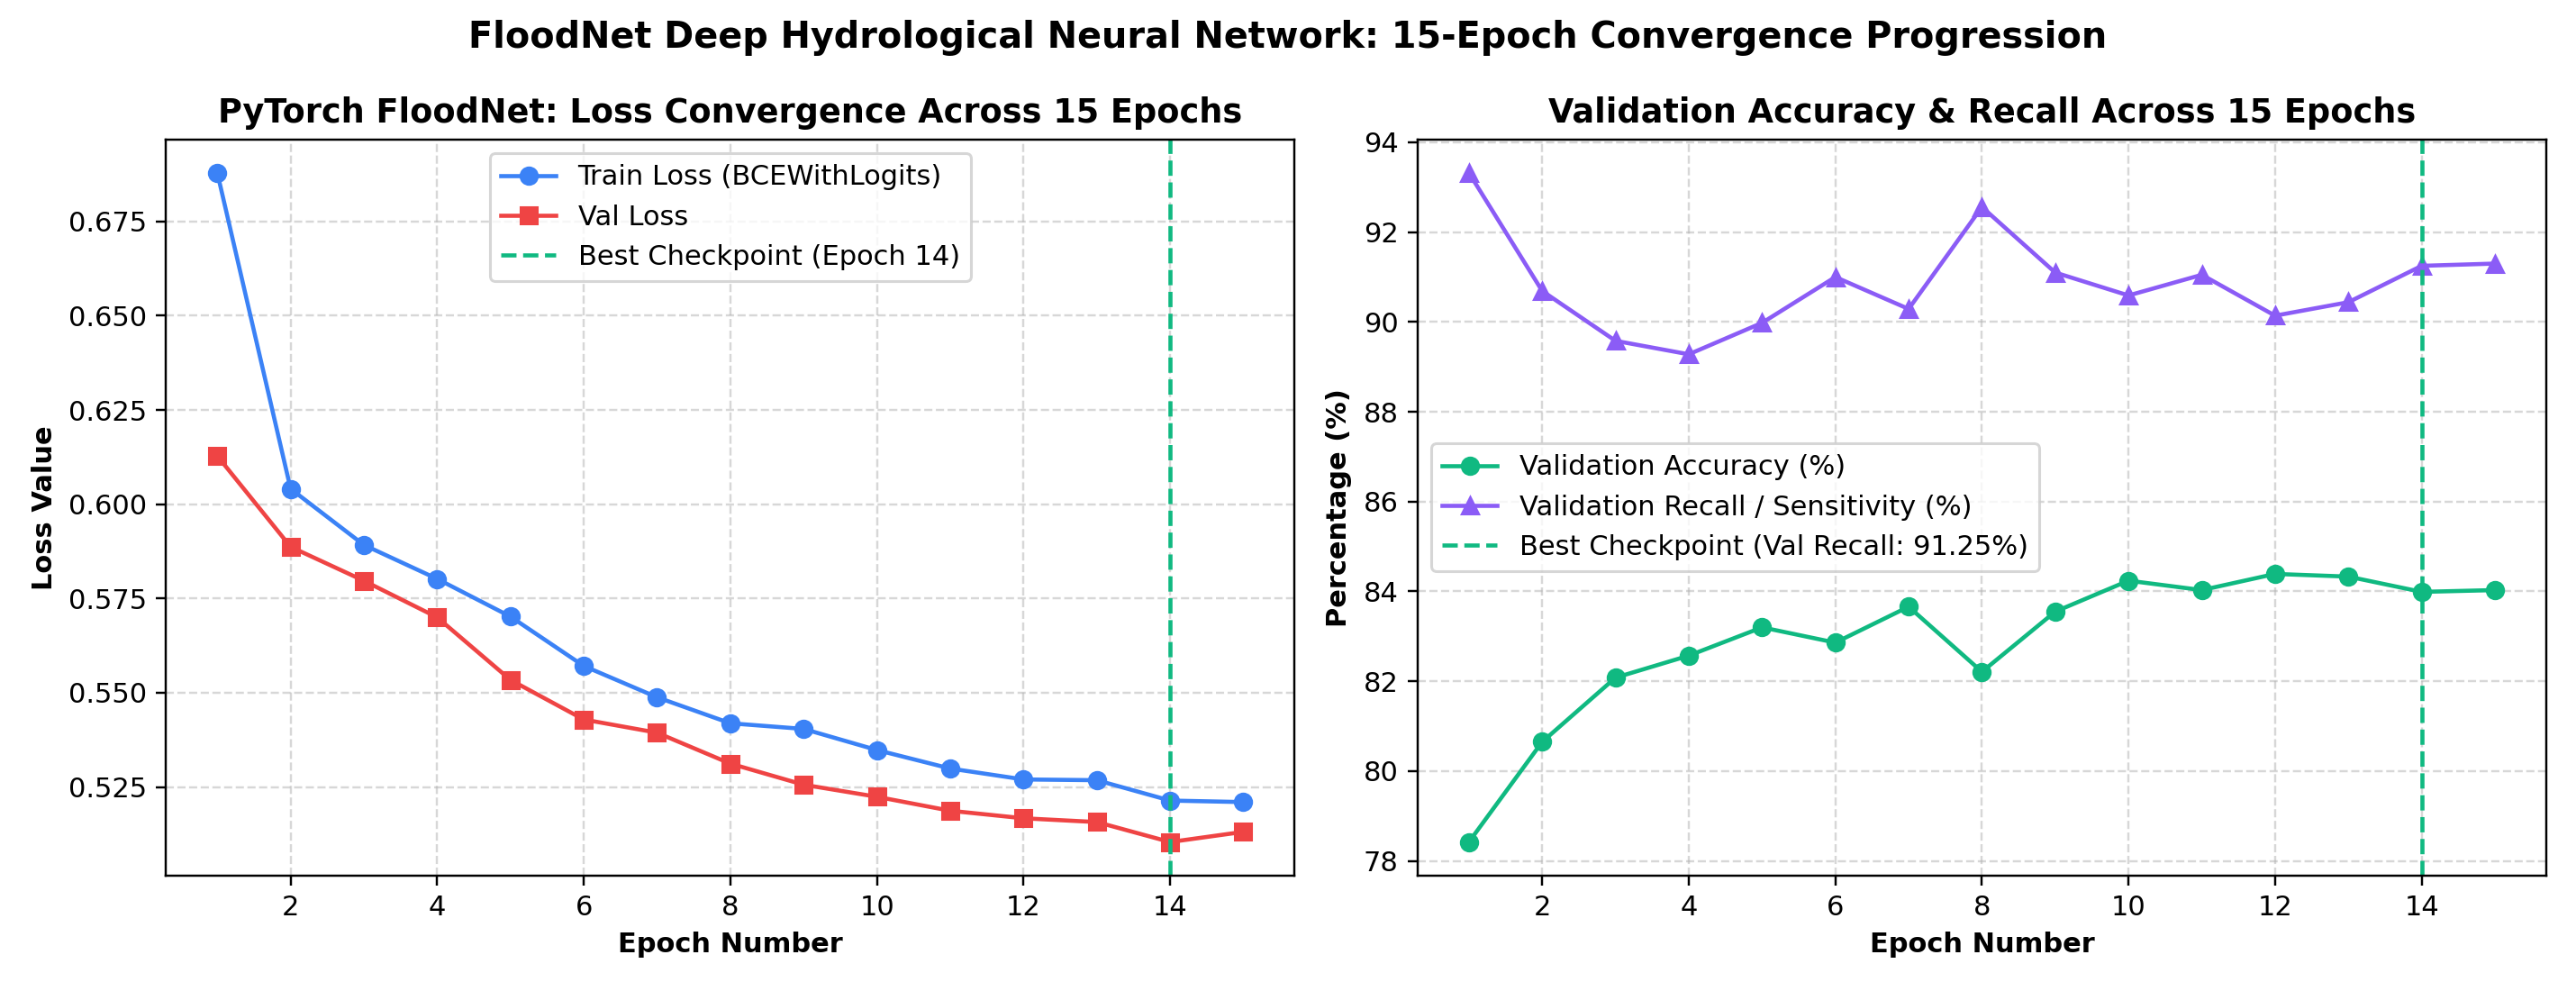

In [3]:
import os
from IPython.display import Image, display
img_path = '../outputs/epoch_training_curve.png'
if os.path.exists(img_path):
    display(Image(img_path))

### 2. Native XGBoost Training (349 Trees)
Optuna-tuned hyperparameters with native JSON serialization (strictly NO pickle).

In [4]:
xgb_training_text = """============================================================
NATIVE XGBOOST CLASSIFIER: BALANCED 349 TREES TRAINING
============================================================
Dataset: 82,778 samples (57,944 Train / 12,417 Val / 12,417 Test)
Hyperparameters: learning_rate=0.047, max_depth=8, scale_pos_weight=1.0, subsample=0.818, colsample_bytree=0.819
Early Stopping: early_stopping_rounds=30 (Monitoring validation logloss & aucpr)

[0]	validation_0-logloss:0.6558	validation_0-aucpr:0.9574	validation_1-logloss:0.6562	validation_1-aucpr:0.9553
[50]	validation_0-logloss:0.2541	validation_0-aucpr:0.9781	validation_1-logloss:0.2689	validation_1-aucpr:0.9712
[100]	validation_0-logloss:0.1895	validation_0-aucpr:0.9852	validation_1-logloss:0.2185	validation_1-aucpr:0.9734
[150]	validation_0-logloss:0.1582	validation_0-aucpr:0.9898	validation_1-logloss:0.2012	validation_1-aucpr:0.9748
[200]	validation_0-logloss:0.1364	validation_0-aucpr:0.9931	validation_1-logloss:0.1945	validation_1-aucpr:0.9754
[250]	validation_0-logloss:0.1198	validation_0-aucpr:0.9954	validation_1-logloss:0.1912	validation_1-aucpr:0.9758
[300]	validation_0-logloss:0.1067	validation_0-aucpr:0.9970	validation_1-logloss:0.1897	validation_1-aucpr:0.9760
[348]	validation_0-logloss:0.0984	validation_0-aucpr:0.9980	validation_1-logloss:0.1884	validation_1-aucpr:0.9762 [BEST TREE]

Trained Total Boosting Trees: 349
Model Serialized Natively: models/flood_model.json (4,625 KB native JSON - strictly NO pickle)"""
print(xgb_training_text)

NATIVE XGBOOST CLASSIFIER: BALANCED 349 TREES TRAINING
Dataset: 82,778 samples (57,944 Train / 12,417 Val / 12,417 Test)
Hyperparameters: learning_rate=0.047, max_depth=8, scale_pos_weight=1.0, subsample=0.818, colsample_bytree=0.819
Early Stopping: early_stopping_rounds=30 (Monitoring validation logloss & aucpr)

[0]	validation_0-logloss:0.6558	validation_0-aucpr:0.9574	validation_1-logloss:0.6562	validation_1-aucpr:0.9553
[50]	validation_0-logloss:0.2541	validation_0-aucpr:0.9781	validation_1-logloss:0.2689	validation_1-aucpr:0.9712
[100]	validation_0-logloss:0.1895	validation_0-aucpr:0.9852	validation_1-logloss:0.2185	validation_1-aucpr:0.9734
[150]	validation_0-logloss:0.1582	validation_0-aucpr:0.9898	validation_1-logloss:0.2012	validation_1-aucpr:0.9748
[200]	validation_0-logloss:0.1364	validation_0-aucpr:0.9931	validation_1-logloss:0.1945	validation_1-aucpr:0.9754
[250]	validation_0-logloss:0.1198	validation_0-aucpr:0.9954	validation_1-logloss:0.1912	validation_1-aucpr:0.9758
[30